In [3]:
import numpy as np
from tueplots import bundles
import matplotlib.pyplot as plt
import pickle
import scipy
## setting matplotlib context
from cycler import cycler
from matplotlib.cm import get_cmap
cmap = get_cmap("tab10",8)
palette = [cmap(i) for i in range(8)]
rc = bundles.neurips2024(usetex=False)
rc.update({
    # Set the line/bar color cycle (this is what affects ax.plot)
    "axes.prop_cycle": cycler(color=palette),
    # Optional readability tweaks
    "legend.frameon": False,
    "axes.grid": False,
})

/var/folders/cx/cy7pq56x7m32_zfmgnslz8cnlnlryt/T/ipykernel_90206/373850321.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab10",8)


In [4]:
# import glob
# def getkey(f):
#     return int(f.split(".")[0].split("_")[-2])

# files = glob.glob("results/adult_balanced/Seed=42/T=10000/stats_target*.pkl")
# files = sorted(files,key=getkey)

# data = []
# for file in files:
#     with open(file, "rb") as f:
#         arr = pickle.load(f)
#     data.append(arr[:,:,0]) 

# stats = np.concatenate(data,axis=0)

# with open("results/adult_balanced/Seed=42/T=10000/stats_target.pkl","wb") as f:
#     pickle.dump(stats,f)

In [5]:
with open("results/adult_balanced/Seed=42/T=10000/in_indices_target.pkl","rb") as f:
    in_indices = pickle.load(f)
with open("results/adult_balanced/Seed=42/T=10000/stats_target.pkl","rb") as f:
    stats = pickle.load(f)

in_indices.shape, stats.shape

((10001, 10000), (10001, 10000))

In [6]:

M, N = stats.shape
assert in_indices.shape == (M, N), "in_indices must be (M, N)"

Rs = np.arange(1,6)*1000
alpha = 0.01

TPR_concat, TPR_concat_pp, TPR_px, TPR_px_ana = np.zeros(len(Rs)), np.zeros(len(Rs)),np.zeros(len(Rs)), np.zeros(len(Rs))

for r in range(len(Rs)):
    R = Rs[r] * 2
    curr_stats, curr_in_indices = stats[:R,:], in_indices[:R,:]
    # ------------------------------------------------------------------
    # 1. Per-sample IN / OUT means + OUT stdev
    # ------------------------------------------------------------------
    in_scores  = np.where(curr_in_indices,  curr_stats, np.nan)   # (M, N)
    out_scores = np.where(~curr_in_indices, curr_stats, np.nan)   # (M, N)

    mu_in  = np.nanmean(in_scores,  axis=0)   # (N,)
    mu_out = np.nanmean(out_scores, axis=0)   # (N,)

    sigma_out = np.nanstd(out_scores, ddof=1, axis=0)   # (N,)

    # --------------------------------------------
    # 2. Per-sample Statistics, Post-Processed
    # --------------------------------------------
    delta_mu = mu_in - mu_out
    curr_stats_pp = (np.sign(delta_mu) * (curr_stats - mu_out)) / sigma_out

    # -------------------------
    # 3. Per-sample Raw LLR
    # -------------------------
    delta_mu = mu_in - mu_out
    llr_px = (delta_mu/ (2*sigma_out**2)) * (2 * curr_stats - (mu_in + mu_out))

    # --------------------------------------------------------------------------
    # 4. Per-sample TPR/FPR from Raw LLRs = Per-Sample TPR/FPR for PP Statistics
    # --------------------------------------------------------------------------

    mask_out = ~curr_in_indices
    mask_in  = curr_in_indices

    tau_px = np.nanquantile(np.where(mask_out, curr_stats, np.nan), 1 - alpha, axis=0)

    fpr_px = (((curr_stats > tau_px) & mask_out).sum(axis=0)
                / mask_out.sum(axis=0))

    tpr_px = (((curr_stats > tau_px) & mask_in).sum(axis=0)
                / mask_in.sum(axis=0))
    TPR_px[r] = tpr_px.mean()
    # print(f" Avg. Per-Sample: TPR = {tpr_px.mean()}/FPR = {fpr_px.mean()}")

    # --------------------------------------------------------------------------
    # 5. Concatenated TPR/FPR from Raw LLRs != Per-Sample TPR/FPR for PP LLRs
    # --------------------------------------------------------------------------

    tau_all = np.nanquantile(np.where(mask_out, llr_px, np.nan), 1 - alpha)

    fpr_all = ((llr_px > tau_all) & mask_out).sum() / mask_out.sum()
    tpr_all = ((llr_px > tau_all) & mask_in).sum() / mask_in.sum()
    TPR_concat[r] = tpr_all
    # print(f" W/O PP: TPR = {tpr_all}/FPR = {fpr_all}")

    tau_all_pp = np.nanquantile(np.where(mask_out, curr_stats_pp, np.nan), 1 - alpha)

    fpr_all_pp = ((curr_stats_pp > tau_all_pp) & mask_out).sum() / mask_out.sum()
    tpr_all_pp = ((curr_stats_pp > tau_all_pp) & mask_in).sum() / mask_in.sum()
    TPR_concat_pp[r] = tpr_all_pp
    # print(f" W/ PP: TPR = {tpr_all_pp}/FPR = {fpr_all_pp}")

    # --------------------------------------------------------------------------
    # 5. Avg Per-Example TPR/FPR from Analytical Threshold
    # --------------------------------------------------------------------------
    tau_analytical = scipy.stats.norm.ppf(1-alpha)

    avg_fpr_px_ana = (((curr_stats_pp > tau_analytical) & mask_out).sum(axis=0)
                / mask_out.sum(axis=0))

    avg_tpr_px_ana = (((curr_stats_pp > tau_analytical) & mask_in).sum(axis=0)
                / mask_in.sum(axis=0))
    TPR_px_ana[r] = avg_tpr_px_ana.mean()

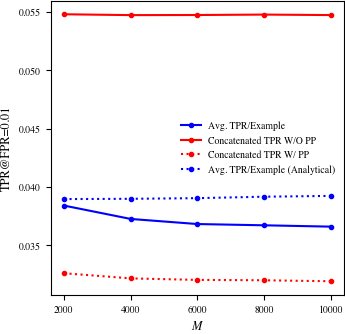

In [7]:
with plt.rc_context(rc):
    fig ,ax = plt.subplots(1,1)
    ax.plot(2*Rs, TPR_px, color="b",marker=".",label="Avg. TPR/Example")
    ax.plot(2*Rs, TPR_concat,color="r",marker=".", label="Concatenated TPR W/O PP")
    ax.plot(2*Rs, TPR_concat_pp,color="r", linestyle=":",marker=".",label="Concatenated TPR W/ PP")
    ax.plot(2*Rs, TPR_px_ana,color="b", linestyle=":",marker=".",label="Avg. TPR/Example (Analytical)")
    ax.set(xlabel=r"$M$",ylabel=f"TPR@FPR={alpha}", xticks=2*Rs)
    ax.legend()
    ax.set_box_aspect(1)
    # plt.savefig(f"lira_px_vs_concat_N_{N}_N_train_{N//2}_fpr_{alpha}_v2.pdf",bbox_inches="tight")
    plt.show()

In [8]:
M, N = stats.shape
assert in_indices.shape == (M, N), "in_indices must be (M, N)"

Rs = 10000
alpha = 0.01

in_scores  = np.where(in_indices,  stats, np.nan)   # (M, N)
out_scores = np.where(~in_indices, stats, np.nan)   # (M, N)

mu_in  = np.nanmean(in_scores,  axis=0)   # (N,)
mu_out = np.nanmean(out_scores, axis=0)   # (N,)
sigma_out = np.nanstd(out_scores, ddof=1, axis=0)   # (N,)
delta_mu = mu_in - mu_out
stats_pp = (np.sign(delta_mu) * (stats - mu_out)) / sigma_out


delta_mu = mu_in - mu_out
llr_px = (delta_mu/ (2*sigma_out**2)) * (2 * stats - (mu_in + mu_out)) # from long-slot slides

mask_out = ~in_indices
mask_in  = in_indices

tau_pp = np.nanquantile(np.where(mask_out, stats_pp, np.nan), 1 - alpha)

fpr_px_pp = (((stats_pp > tau_pp) & mask_out).sum(axis=0)
            / mask_out.sum(axis=0))

tau = np.nanquantile(np.where(mask_out, llr_px, np.nan), 1 - alpha)

fpr_px = (((llr_px > tau) & mask_out).sum(axis=0)
            / mask_out.sum(axis=0))


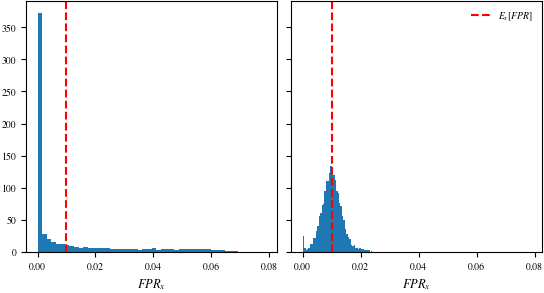

In [9]:
with plt.rc_context(rc):
    fig, ax = plt.subplots(1,2,sharex="row",sharey="row")
    ax[0].hist(fpr_px,bins=50,density=True)
    ax[0].axvline(x=0.01,color="r",linestyle="--",label=rf"$E_x[FPR]$")
    ax[0].set(xlabel=rf"$FPR_x$")
    ax[0].set_box_aspect(1)

    ax[1].hist(fpr_px_pp,bins=50,density=True)
    ax[1].axvline(x=0.01,color="r",linestyle="--",label=rf"$E_x[FPR]$")
    ax[1].set(xlabel=rf"$FPR_x$")
    ax[1].set_box_aspect(1)
    
    ax[1].legend()
    # plt.savefig("px_fprs_at_concat_tau.pdf",bbox_inches="tight")
    plt.show()